In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../Top_Spotify_songs.csv')
df = df[df["country"] == "MX"]
df.head()
print(df.columns)

Index(['spotify_id', 'name', 'artists', 'daily_rank', 'daily_movement',
       'weekly_movement', 'country', 'snapshot_date', 'popularity',
       'is_explicit', 'duration_ms', 'album_name', 'album_release_date',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature'],
      dtype='object')


In [2]:
# Average Song Attributes
avg_song = {"key": df["key"].mean(),
            "mode": df["mode"].mean(),
            "time_signature": df["time_signature"].mean(),
            "liveness": df["liveness"].mean(),
            "speechiness": df["speechiness"].mean(),
            "loudness": df["loudness"].mean(),
            "tempo": df["tempo"].mean(),
            "duration_ms": df["duration_ms"].mean(),
            "danceability": df["danceability"].mean(),
            "energy": df["energy"].mean(),
            "valence": df["valence"].mean(),
            "acousticness": df["acousticness"].mean(),
            "instrumentalness": df["instrumentalness"].mean()}

std_dev_song = {"key": df["key"].std(),
                "mode": df["mode"].std(),
                "time_signature": df["time_signature"].std(),
                "liveness": df["liveness"].std(),
                "speechiness": df["speechiness"].std(),
                "loudness": df["loudness"].std(),
                "tempo": df["tempo"].std(),
                "duration_ms": df["duration_ms"].std(),
                "danceability": df["danceability"].std(),
                "energy": df["energy"].std(),
                "valence": df["valence"].std(),
                "acousticness": df["acousticness"].std(),
                "instrumentalness": df["instrumentalness"].std()}



avg_df = pd.DataFrame({
    'Mean': avg_song,
    'Standard Deviation': std_dev_song,
    'Upper_Bin': None,
    'Lower_Bin': None
})

## https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule
for key in avg_song:
    avg_df.at[key, 'Upper_Bin'] = avg_song[key] + (1.5 * std_dev_song[key])
    avg_df.at[key, 'Lower_Bin'] = avg_song[key] - (1.5 * std_dev_song[key])
    avg_df = avg_df.round(2)
    
print(avg_df)


                       Mean  Standard Deviation      Upper_Bin      Lower_Bin
key                    6.00                3.30      10.953178       1.047746
mode                   0.47                0.50       1.213603       -0.28283
time_signature         3.42                0.63       4.362457       2.480943
liveness               0.16                0.10        0.30908       0.013082
speechiness            0.07                0.07       0.173517      -0.024231
loudness              -6.43                3.70      -0.870862     -11.979388
tempo                124.08               23.75      159.70564       88.46322
duration_ms       187431.92            34323.30  238916.866485  135946.981117
danceability           0.73                0.10       0.890376       0.575686
energy                 0.69                0.15       0.911685       0.473751
valence                0.68                0.20       0.977168       0.385539
acousticness           0.28                0.21        0.59813  

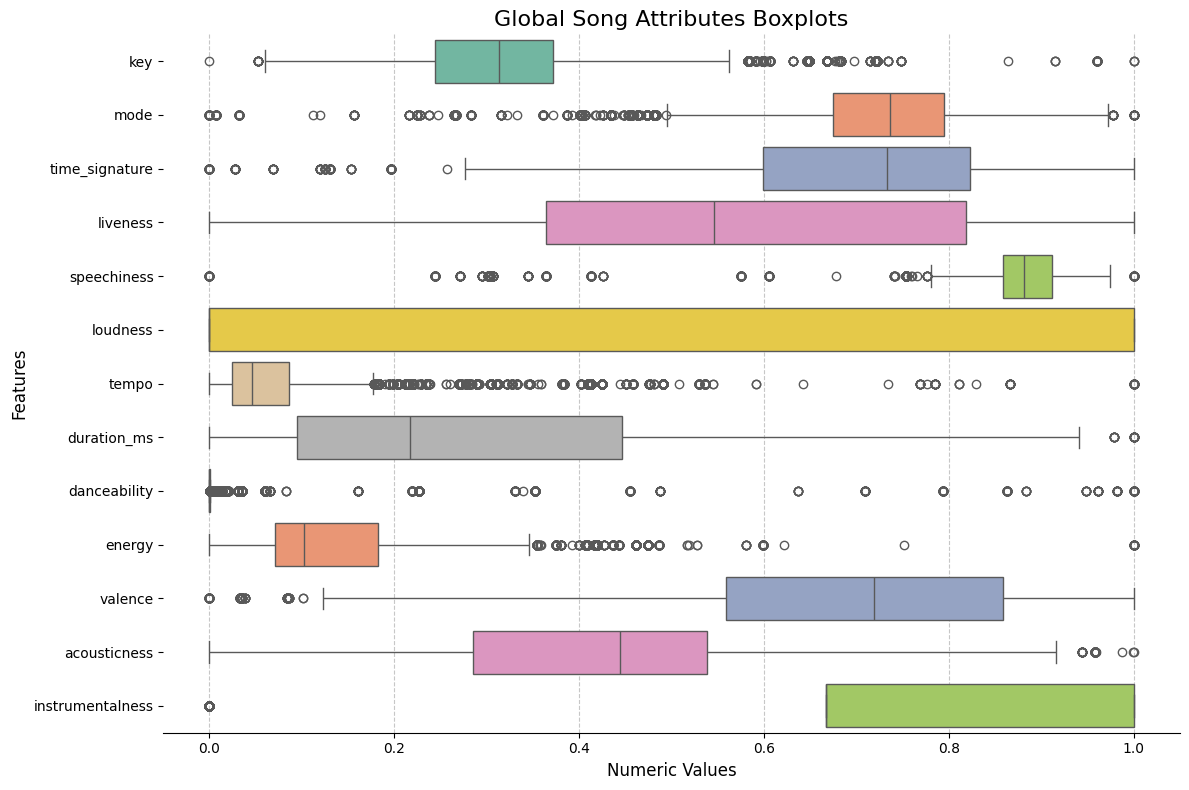

In [3]:
# Normalization
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
scaler = MinMaxScaler()

scaled = df.drop(columns=["spotify_id", "name", "artists", "daily_rank", "daily_movement", "weekly_movement", 
                              "popularity", "is_explicit", "snapshot_date", "country", "album_name", "album_release_date"], axis=1, inplace=False)

scaled = scaler.fit_transform(scaled)

scaled_df = pd.DataFrame(scaled, columns=["key", "mode", "time_signature", "liveness", "speechiness", "loudness", "tempo", "duration_ms", "danceability", "energy", "valence", "acousticness", "instrumentalness"])
# print(scaled_df)

scaled_mean = {"key": scaled_df["key"].mean(),
            "mode": scaled_df["mode"].mean(),
            "time_signature": scaled_df["time_signature"].mean(),
            "liveness": scaled_df["liveness"].mean(),
            "speechiness": scaled_df["speechiness"].mean(),
            "loudness": scaled_df["loudness"].mean(),
            "tempo": scaled_df["tempo"].mean(),
            "duration_ms": scaled_df["duration_ms"].mean(),
            "danceability": scaled_df["danceability"].mean(),
            "energy": scaled_df["energy"].mean(),
            "valence": scaled_df["valence"].mean(),
            "acousticness": scaled_df["acousticness"].mean(),
            "instrumentalness": scaled_df["instrumentalness"].mean()}

scaled_std = {"key": scaled_df["key"].std(),
                "mode": scaled_df["mode"].std(),
                "time_signature": scaled_df["time_signature"].std(),
                "liveness": scaled_df["liveness"].std(),
                "speechiness": scaled_df["speechiness"].std(),
                "loudness": scaled_df["loudness"].std(),
                "tempo": scaled_df["tempo"].std(),
                "duration_ms": scaled_df["duration_ms"].std(),
                "danceability": scaled_df["danceability"].std(),
                "energy": scaled_df["energy"].std(),
                "valence": scaled_df["valence"].std(),
                "acousticness": scaled_df["acousticness"].std(),
                "instrumentalness": scaled_df["instrumentalness"].std()}


# scaled_df = pd.DataFrame({
#     'Mean': scaled_mean,
#     'Standard Deviation': scaled_std,
#     'Upper_Bin': None,
#     'Lower_Bin': None
# })

# for key in scaled_mean:
#     scaled_df.at[key, 'Upper_Bin'] = scaled_mean[key] + (1.5 * scaled_std[key])
#     scaled_df.at[key, 'Lower_Bin'] = scaled_mean[key] - (1.5 * scaled_std[key])
#     scaled_df = avg_df.round(2)

# print(scaled_df)

plt.figure(figsize=(12, 8))  # Increase figure size for better readability
sns.boxplot(data=scaled_df, orient='h', palette='Set2')  # Horizontal boxes and a nicer palette
plt.title("Global Song Attributes Boxplots", fontsize=16)  # Larger title
plt.xlabel("Numeric Values", fontsize=12)  # Label x-axis
plt.ylabel("Features", fontsize=12)  # Label y-axis
plt.xticks(fontsize=10)  # Increase tick font size
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add a subtle grid
sns.despine(left=True) #remove the left spine.
plt.tight_layout() #prevents labels from being cut off.
plt.show()


average_song
Higher           9059
Lower            7675
About_Average    7072
Name: count, dtype: int64


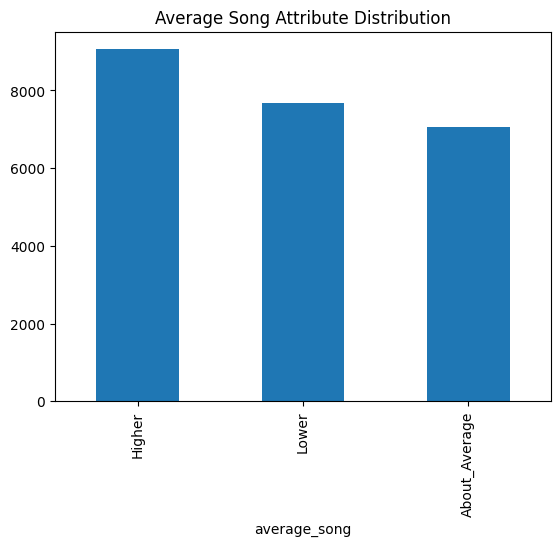

         daily_rank  daily_movement  weekly_movement    popularity  \
count  23806.000000    23806.000000     23806.000000  23806.000000   
mean      25.497690        0.526044         1.641645     83.799168   
std       14.430547        5.200259         9.842541      8.998805   
min        1.000000      -36.000000       -32.000000      0.000000   
25%       13.000000       -1.000000        -3.000000     81.000000   
50%       25.500000        0.000000         0.000000     84.000000   
75%       38.000000        1.000000         3.000000     88.000000   
max       50.000000       49.000000        49.000000    100.000000   

         duration_ms  danceability        energy           key      loudness  \
count   23806.000000  23806.000000  23806.000000  23806.000000  23806.000000   
mean   187431.923801      0.733031      0.692718      6.000462     -6.425125   
std     34323.295123      0.104897      0.145978      3.301811      3.702842   
min     95000.000000      0.142000      0.003320 

In [4]:
def classify_song(row):
    upper_count = 0
    lower_count = 0
    
    features = {
        'key': row['key'],
        'mode': row['mode'],
        'time_signature': row['time_signature'],
        'liveness': row['liveness'],
        'speechiness': row['speechiness'],
        'loudness': row['loudness'],
        'tempo': row['tempo'],
        'duration_ms': row['duration_ms'],
        'danceability': row['danceability'],
        'energy': row['energy'],
        'valence': row['valence'],
        'acousticness': row['acousticness'],
        'instrumentalness': row['instrumentalness']
    }

    for feat, value in features.items():
        upper_bound = avg_df.at[feat, 'Upper_Bin']
        lower_bound = avg_df.at[feat, 'Lower_Bin']
        
        if value > upper_bound:
            upper_count += 1
        elif value <= lower_bound:
            lower_count += 1

    #  logic
    total_outliers = upper_count + lower_count
    if total_outliers == 0:
        return "About_Average"
    
    # if more than 1/2 of the features higher than the average bin, than classify as higher
    # if more than 1/2 of the features lower than the average bin, than classify as lower
    outside_ratio = upper_count / total_outliers
    #print(outside_ratio)
    if outside_ratio > .5:
        #print("Higher")
        return "Higher"
    elif outside_ratio <= 0.5:
        #print("Lower")
        return "Lower"

    
df['average_song'] = df.apply(classify_song, axis=1)
print(df['average_song'].value_counts())
df['average_song'].value_counts().plot(kind='bar', title='Average Song Attribute Distribution')
plt.show()
print(df.describe())

In [5]:
df.to_csv('../MX_with_labels.csv', index=False) #US_with_labels, MX_with_labels, CA_with_labels
df_mod = pd.read_csv('../MX_with_labels.csv') #US_with_labels, MX_with_labels, CA_with_labels
df_mod.head()

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,average_song
0,5Z75FvRFiultmPFWHx5jQ7,7 Dias,"Gabito Ballesteros, Tito Double P",1,0,1,MX,2025-02-17,85,True,...,-3.749,1,0.0614,0.3860,0.000000,0.0839,0.577,111.913,3,Higher
1,78HEzDEs1QUnHB2DbxgC1s,Te Quería Ver,"Alemán, Neton Vega",2,1,1,MX,2025-02-17,82,False,...,-5.182,0,0.0681,0.1880,0.000017,0.0922,0.448,100.019,4,About_Average
2,0LTwdL5yZ6YOTEGUQPFuSN,ROSONES,Tito Double P,3,1,1,MX,2025-02-17,88,True,...,-5.939,1,0.0318,0.7040,0.000010,0.1170,0.604,120.129,3,Lower
3,7sd6zMrgGpEa7NkQm9TRrg,NADIE,Tito Double P,4,1,2,MX,2025-02-17,87,True,...,-4.710,1,0.1140,0.4650,0.000000,0.1200,0.526,92.604,4,About_Average
4,4eLDmhsJW3JoZTXCAozHor,Loco,Neton Vega,5,-3,45,MX,2025-02-17,61,False,...,-5.502,1,0.0686,0.0741,0.007680,0.1390,0.636,91.981,4,Lower
